2.0161145669781555
76.82316572527058
[0.45538156840213345, 0.07892214466816992, 0.033375308184563676, 0.028233307338224396]
[0. 0. 0. 0. 0.]
1.2759475029868403


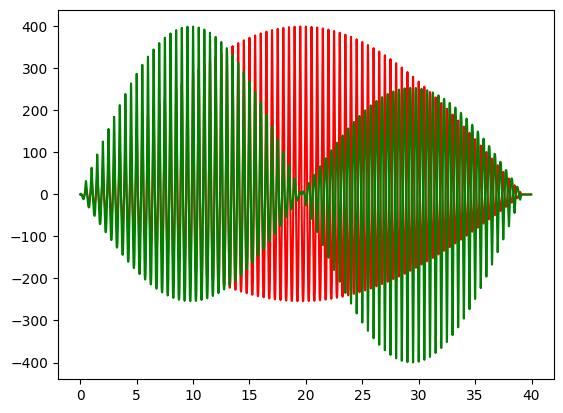

In [65]:
import math
import numpy as np
import random
from matplotlib import pyplot as plt
from pedestrian import *
from scipy.signal import welch, detrend, butter, filtfilt
from solver import* #Phi_matrix ,accdyn_super,MatrixAssemblesymetric,calculate_frf_and_accelerance,g_pj
from matrix import bridge


#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 1
pedmass =70      #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz


modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers =numbers  )                   #modes


N_bridge = 2




# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= 70 #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])

alpha_COV= np.array([0.17,0.4,0.4,0.4])


alpha_std = mean_alpha*alpha_COV

# Generate a random variable from a normal distribution with considered mean and std_dev from literiture

randomPace = random.gauss(mean_pace, pace_COV*mean_pace)
randomMass = random.gauss(mean_mass, mass_COV*mean_mass)
randomAlpha = [random.gauss(mean_alpha[i], alpha_std[i]) for i in range(len(alpha_COV))]
#randomPhase = [random.uniform(0, 2 * math.pi) for i in range(len(mean_alpha)+1)]
randomVelocity = random.gauss(mean_velocity,std_velocity)
randomPhase = np.zeros(5)


#ped
kped1=(2*np.pi*pedBodyF)**2*pedmass
cped1 = (2*np.pi*pedBodyF)*2*peddamp*pedmass

mped = np.array([pedmass])
cped = np.array([cped1])
kped = np.array([kped1])



t = np.array(np.arange(0, (length + 1) / randomVelocity, hht))

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
        iSync=0)
'''
Human = Pedestrian(
         mass = randomMass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = randomPace ,    #Hz
         phase = randomPhase,
         location = pedInlocation,
         velocity = randomVelocity,
         
         iSync=0)'''

#ped = RandPedestrian(randomMass, randomPace, randomPhase, randomAlpha)
n=1
numped=1
#j=np.size(t)
xr=[0]
#force_at_time_t = np.zeros(np.size(t))


#modal force
F=np.zeros((N_bridge,np.size(t)))
for i in range (np.size(t)):
     
    force_at_time_t = calcDynamicPedForce(Human,t[i])         #calculates the human force at time t
    NN=Phi_matrix(xr,length,linearMass,N_bridge,numped)       #mode shape
    F[:,[i]] = (linearMass*length/2) ** 0.5*NN * force_at_time_t                           #modalforce
    xr=np.add(xr,randomVelocity*hht)


plt.plot(t, F[0, :], label="mod 1", color='r')  # First row
plt.plot(t, F[1, :], label="mod 2", color='g')  # Second row
plt.show()


1025
2050
1025
42


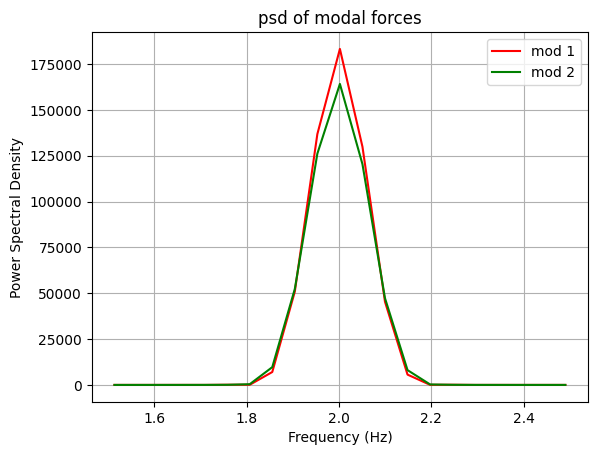

In [70]:
fs = 1/hht 
frequencies, psd_temp = welch(F[0, :], fs=fs, nperseg=1024, nfft=2048)  # Run welch once to determine size
psd_values = np.zeros((N_bridge, len(psd_temp))) 
#psd_values = np.zeros((N_bridge,np.size(t)))

# Loop through each row of matrix F (each mode) and compute its PSD
for i in range(N_bridge):  # Loop over each row (mode)
    frequencies, psd_values[[i],:] = welch(F[i, :], fs=fs, nperseg=1024, noverlap=0.75*1024 ,nfft=2048)  # Adjust nperseg as needed
print(np.size(frequencies))    
print(np.size(psd_values))

selected_frequencies = frequencies[(frequencies >= 1.5) & (frequencies <= 2.5)]
indices = np.where((frequencies >= 1.5) & (frequencies <= 2.5))

# Get the corresponding values from amplitudes
psd= psd_values[:,indices[0]]
#frequencies=frequencies[frequencies<(10)] #adjust range of frequency range suitable for analysis
#psd=psd_values[:,:np.size(frequencies)]   
print(np.size(frequencies))
print(np.size(psd))

# Plot the PSD for each mode
plt.figure()  
plt.plot(selected_frequencies, psd[0,:], label="mod 1", color='r')
plt.plot(selected_frequencies, psd[1,:], label="mod 2", color='g')
#plt.plot(frequencies, psd[2,:], label="mod 3", color='b')
#plt.plot(frequencies, psd[3,:], label="mod 4", color='orange')
plt.title("psd of modal forces")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.grid()
plt.show()

0.04999999999999999
0.3141592653589792
200
200
400
1800


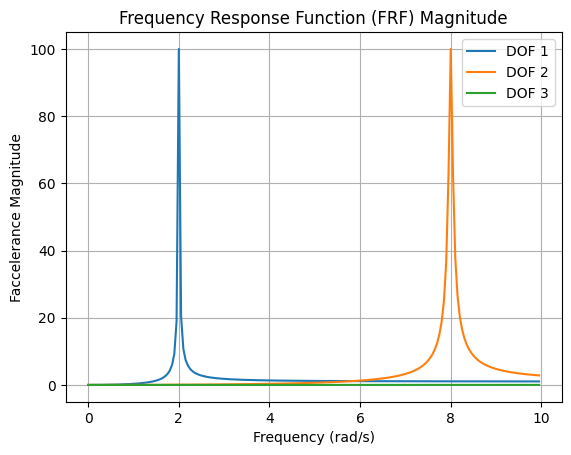

In [28]:

M,K,C,_=MatrixAssemble(Human,Bridge,mped,kped,cped,xrb,length,linearMass,N_bridge,numped,t[3500])
frequency_range =  frequencies*2*np.pi
#frequency_range = np.arange(0.1,63,0.1)
_,accelerance = calc_frf(M,C,K,frequency_range)
deltaF= frequencies[4]-frequencies[3]
deltaF2 =frequency_range[4]-frequency_range[3]
print(deltaF)
print(deltaF2)
print(np.size(frequencies))
print(np.size(frequency_range))
print(np.size(psd))
print(np.size(accelerance))



n_dof = M.shape[0]
for dof in range(n_dof):
    plt.plot(frequency_range/(2*np.pi), np.abs(accelerance[dof, dof, :]), label=f'DOF {dof + 1}')
    plt.xlabel('Frequency (rad/s)')
    plt.ylabel('Faccelerance Magnitude')
    plt.title('Frequency Response Function (FRF) Magnitude')
    plt.legend()
    plt.grid(True)
plt.show()

In [46]:
from scipy.integrate import quad
frequency_range =  frequencies*2*np.pi   #in radians/sec
#frequencies=frequencies[:np.size(frequency_range)] #adjust range of frequency range suitable for analysis
#psd=psd_values[:,:np.size(frequency_range)] 
variance = np.zeros((N_bridge, np.size(frequency_range)))
deltaF= frequency_range[4]-frequency_range[3]
modal_peak_accn = np.zeros((N_bridge, np.size(t)))
for i in range(np.size(t)):
    M,K,C,_=MatrixAssemblesymetric(Human,Bridge,mped,kped,cped,xrb,length,linearMass,N_bridge,numped,t[i])
    _,accelerance = calc_frf(M,C,K,frequency_range)
    
    for j in range(1):
        for kp in range(1):
            variance[j,:] =np.add(variance[j,:], ((np.abs(accelerance[j,kp,:]))**2)*psd[kp,:])
    #variance[j, :] = variance[j, :np.size(frequencies)]
   # integrand = lambda f: np.interp(f, frequencies, variance[j, :], left=0, right=0)
   # sigma_2, _ = quad(integrand, frequencies[0], frequencies[-1])
    sigma_2=np.trapz(variance[0,:], dx=0.05)
    sigma=np.sqrt(sigma_2)
    g_pj_value= g_pj(beamFreq,1,length,pedvelocity)
    modal_peak_accn[0,[i]]= g_pj_value*sigma

IndexError: index 0 is out of bounds for axis 0 with size 0

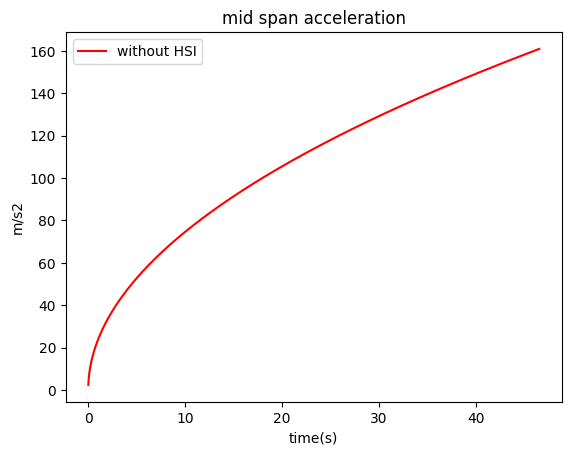

In [36]:
phi_x=Phi_x(length/2,length,linearMass,N_bridge)
peakaccn= phi_x[0,0]*modal_peak_accn[0,:]
plt.plot(t,peakaccn , label ="without HSI" ,color='r')
#plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
#plt.plot(t,vertical_displacement)  
plt.show()

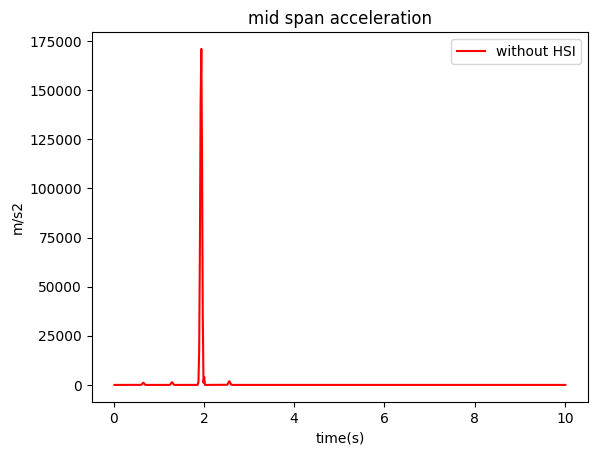

In [21]:
M,K,C,_=MatrixAssemblesymetric(Human,Bridge,mped,kped,cped,xrb,length,linearMass,N_bridge,numped,t[2000])
_,accelerance = calc_frf(M,C,K,frequency_range)
    
for j in range(1):
    for kp in range(N_bridge):
        variance[j,:] += ((np.abs(accelerance[j,kp,:]))**2)*psd[kp,:]
    #variance[j, :] = variance[j, :np.size(frequencies)]

plt.plot(frequency_range/(2*np.pi),variance[0,:] , label ="without HSI" ,color='r')
#plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
#plt.plot(t,vertical_displacement)  
plt.show()

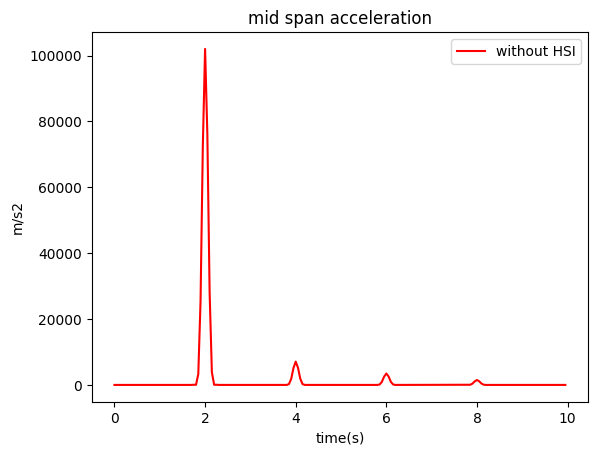

In [44]:
sigma_2_analytical =psd[0,:]*2*np.pi*frequency_range/(2*modalDampingRatio)
sigma_analytical=np.sqrt(sigma_2_analytical)
g_pj_value= g_pj(beamFreq,10,length,pedvelocity)
modal_peak_accn[0,[i]]= g_pj_value*sigma
plt.plot(frequency_range/(2*np.pi),sigma_2_analytical , label ="without HSI" ,color='r')
#plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
#plt.plot(t,vertical_displacement)  
plt.show()

In [49]:
import pandas as pd
sigma_2_analytical =psd[0,:]*2*np.pi*frequency_range/(2*modalDampingRatio)
data = pd.DataFrame({'x': frequency_range, 'y': sigma_2_analytical})
y_value = data.loc[data['x'] == 2*2*np.pi, 'y'].values[0]
sigma_analytical=np.sqrt(y_value)
g_pj_value= g_pj(beamFreq,10,length,pedvelocity)
modal_peak_accn[0,[i]]= g_pj_value*sigma_analytical
print(modal_peak_accn[0,[i]])

[1118.47100216]
